<a href="https://colab.research.google.com/github/rishitha067/Healthcare-Fraud-Detection/blob/main/Healthcare_Provider_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Healthcare Provider Fraud Detection

## Project Objective

The objective of this project is to predict potentially fraudulent healthcare providers using Medicare claim records. The project involves data management, exploratory data analysis, feature engineering, feature selection, machine learning model development, evaluation, and prediction on unseen providers.

## Dataset

The project consists of four datasets:

- Provider Training Data
- Beneficiary Data
- Inpatient Claims
- Outpatient Claims

The unseen dataset contains providers for which fraud predictions must be generated.

In [ ]:
!git clone https://github.com/rishitha067/Healthcare-Fraud-Detection.git

Cloning into 'Healthcare-Fraud-Detection'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 16 (delta 0), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), done.
Filtering content: 100% (8/8), 117.94 MiB | 24.38 MiB/s, done.


In [ ]:
%cd Healthcare-Fraud-Detection

/content/Healthcare-Fraud-Detection


In [ ]:
!apt-get update -qq
!apt-get install git-lfs -y
!git lfs install
!git lfs pull

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  git-lfs
0 upgraded, 1 newly installed, 0 to remove and 134 not upgraded.
Need to get 3,544 kB of archives.
After this operation, 10.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 git-lfs amd64 3.0.2-1ubuntu0.3 [3,544 kB]
Fetched 3,544 kB in 0s (7,540 kB/s)
Selecting previously unselected package git-lfs.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.0.2-1ubuntu0.3_amd64.deb ...
Unpacking git-lfs (3.0.2-1ubuntu0.3) ...
Setting up git-lfs (3.0.2-1ubuntu0.3) ...
Processing triggers for man-db (2.10.2-1) ...
Hook already exists: pre-push


In [ ]:
!ls

data


In [ ]:
!ls data

README.md
Train-1542865627584.csv
Train_Beneficiarydata-1542865627584.csv
Train_Inpatientdata-1542865627584.csv
Train_Outpatientdata-1542865627584.csv
Unseen-1542969243754.csv
Unseen_Beneficiarydata-1542969243754.csv
Unseen_Inpatientdata-1542969243754.csv
Unseen_Outpatientdata-1542969243754.csv


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd

train = pd.read_csv("data/Train-1542865627584.csv")

beneficiary = pd.read_csv("data/Train_Beneficiarydata-1542865627584.csv")

inpatient = pd.read_csv("data/Train_Inpatientdata-1542865627584.csv")

outpatient = pd.read_csv("data/Train_Outpatientdata-1542865627584.csv")

unseen = pd.read_csv("data/Unseen-1542969243754.csv")

unseen_beneficiary = pd.read_csv("data/Unseen_Beneficiarydata-1542969243754.csv")

unseen_inpatient = pd.read_csv("data/Unseen_Inpatientdata-1542969243754.csv")

unseen_outpatient = pd.read_csv("data/Unseen_Outpatientdata-1542969243754.csv")

In [ ]:
print("Train :", train.shape)
print("Beneficiary :", beneficiary.shape)
print("Inpatient :", inpatient.shape)
print("Outpatient :", outpatient.shape)

print("Unseen :", unseen.shape)
print("Unseen Beneficiary :", unseen_beneficiary.shape)
print("Unseen Inpatient :", unseen_inpatient.shape)
print("Unseen Outpatient :", unseen_outpatient.shape)

Train : (5410, 2)
Beneficiary : (138556, 25)
Inpatient : (40474, 30)
Outpatient : (517737, 27)
Unseen : (1353, 1)
Unseen Beneficiary : (63968, 25)
Unseen Inpatient : (9551, 30)
Unseen Outpatient : (125841, 27)


In [ ]:
train.head()

,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


In [ ]:
beneficiary.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,...,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,...,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,...,2,1,2,2,2,2,0,0,1790,1200


In [ ]:
inpatient.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
outpatient.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947


In [ ]:
print("Train Columns")
print(train.columns.tolist())

Train Columns
['Provider', 'PotentialFraud']


In [ ]:
print("Beneficiary Columns")
print(beneficiary.columns.tolist())

Beneficiary Columns
['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']


In [ ]:
print("Inpatient Columns")
print(inpatient.columns.tolist())

Inpatient Columns
['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6']


In [ ]:
print("Outpatient Columns")
print(outpatient.columns.tolist())

Outpatient Columns
['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DeductibleAmtPaid', 'ClmAdmitDiagnosisCode']


In [ ]:
print(train.isnull().sum())

Provider          0
PotentialFraud    0
dtype: int64


In [ ]:
print(beneficiary.isnull().sum())

BeneID                                  0
DOB                                     0
DOD                                137135
Gender                                  0
Race                                    0
RenalDiseaseIndicator                   0
State                                   0
County                                  0
NoOfMonths_PartACov                     0
NoOfMonths_PartBCov                     0
ChronicCond_Alzheimer                   0
ChronicCond_Heartfailure                0
ChronicCond_KidneyDisease               0
ChronicCond_Cancer                      0
ChronicCond_ObstrPulmonary              0
ChronicCond_Depression                  0
ChronicCond_Diabetes                    0
ChronicCond_IschemicHeart               0
ChronicCond_Osteoporasis                0
ChronicCond_rheumatoidarthritis         0
ChronicCond_stroke                      0
IPAnnualReimbursementAmt                0
IPAnnualDeductibleAmt                   0
OPAnnualReimbursementAmt          

In [ ]:
print(beneficiary.isnull().sum())

BeneID                                  0
DOB                                     0
DOD                                137135
Gender                                  0
Race                                    0
RenalDiseaseIndicator                   0
State                                   0
County                                  0
NoOfMonths_PartACov                     0
NoOfMonths_PartBCov                     0
ChronicCond_Alzheimer                   0
ChronicCond_Heartfailure                0
ChronicCond_KidneyDisease               0
ChronicCond_Cancer                      0
ChronicCond_ObstrPulmonary              0
ChronicCond_Depression                  0
ChronicCond_Diabetes                    0
ChronicCond_IschemicHeart               0
ChronicCond_Osteoporasis                0
ChronicCond_rheumatoidarthritis         0
ChronicCond_stroke                      0
IPAnnualReimbursementAmt                0
IPAnnualDeductibleAmt                   0
OPAnnualReimbursementAmt          

In [ ]:
print(inpatient.isnull().sum())

BeneID                        0
ClaimID                       0
ClaimStartDt                  0
ClaimEndDt                    0
Provider                      0
InscClaimAmtReimbursed        0
AttendingPhysician          112
OperatingPhysician        16644
OtherPhysician            35784
AdmissionDt                   0
ClmAdmitDiagnosisCode         0
DeductibleAmtPaid           899
DischargeDt                   0
DiagnosisGroupCode            0
ClmDiagnosisCode_1            0
ClmDiagnosisCode_2          226
ClmDiagnosisCode_3          676
ClmDiagnosisCode_4         1534
ClmDiagnosisCode_5         2894
ClmDiagnosisCode_6         4838
ClmDiagnosisCode_7         7258
ClmDiagnosisCode_8         9942
ClmDiagnosisCode_9        13497
ClmDiagnosisCode_10       36547
ClmProcedureCode_1        17326
ClmProcedureCode_2        35020
ClmProcedureCode_3        39509
ClmProcedureCode_4        40358
ClmProcedureCode_5        40465
ClmProcedureCode_6        40474
dtype: int64


In [ ]:
print(outpatient.isnull().sum())

BeneID                         0
ClaimID                        0
ClaimStartDt                   0
ClaimEndDt                     0
Provider                       0
InscClaimAmtReimbursed         0
AttendingPhysician          1396
OperatingPhysician        427120
OtherPhysician            322691
ClmDiagnosisCode_1         10453
ClmDiagnosisCode_2        195380
ClmDiagnosisCode_3        314480
ClmDiagnosisCode_4        392141
ClmDiagnosisCode_5        443393
ClmDiagnosisCode_6        468981
ClmDiagnosisCode_7        484776
ClmDiagnosisCode_8        494825
ClmDiagnosisCode_9        502899
ClmDiagnosisCode_10       516654
ClmProcedureCode_1        517575
ClmProcedureCode_2        517701
ClmProcedureCode_3        517733
ClmProcedureCode_4        517735
ClmProcedureCode_5        517737
ClmProcedureCode_6        517737
DeductibleAmtPaid              0
ClmAdmitDiagnosisCode     412312
dtype: int64


In [ ]:
train.drop_duplicates(inplace=True)

beneficiary.drop_duplicates(inplace=True)

inpatient.drop_duplicates(inplace=True)

outpatient.drop_duplicates(inplace=True)

In [ ]:
print(train.shape)
print(beneficiary.shape)
print(inpatient.shape)
print(outpatient.shape)

(5410, 2)
(138556, 25)
(40474, 30)
(517737, 27)


In [ ]:
print(unseen.shape)
print(unseen_beneficiary.shape)
print(unseen_inpatient.shape)
print(unseen_outpatient.shape)

(1353, 1)
(63968, 25)
(9551, 30)
(125841, 27)


In [ ]:
print(train.columns.tolist())

print(beneficiary.columns.tolist())

print(inpatient.columns.tolist())

print(outpatient.columns.tolist())

['Provider', 'PotentialFraud']
['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']
['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDi

In [ ]:
print(unseen.columns.tolist())

print(unseen_beneficiary.columns.tolist())

print(unseen_inpatient.columns.tolist())

print(unseen_outpatient.columns.tolist())

['Provider']
['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']
['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'C

In [ ]:
date_columns_bene = ['DOB', 'DOD']

for col in date_columns_bene:
    beneficiary[col] = pd.to_datetime(beneficiary[col], errors='coerce')

date_columns_ip = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt']

for col in date_columns_ip:
    inpatient[col] = pd.to_datetime(inpatient[col], errors='coerce')

date_columns_op = ['ClaimStartDt', 'ClaimEndDt']

for col in date_columns_op:
    outpatient[col] = pd.to_datetime(outpatient[col], errors='coerce')

In [ ]:
today = pd.Timestamp("2010-12-31")

beneficiary['Age'] = ((today - beneficiary['DOB']).dt.days / 365).astype(int)

In [ ]:
inpatient['HospitalStay'] = (
    inpatient['DischargeDt'] -
    inpatient['AdmissionDt']
).dt.days

In [ ]:
inpatient['HospitalStay'] = inpatient['HospitalStay'].fillna(0)

In [ ]:
chronic_columns = [
    'ChronicCond_Alzheimer',
    'ChronicCond_Heartfailure',
    'ChronicCond_KidneyDisease',
    'ChronicCond_Cancer',
    'ChronicCond_ObstrPulmonary',
    'ChronicCond_Depression',
    'ChronicCond_Diabetes',
    'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis',
    'ChronicCond_rheumatoidarthritis',
    'ChronicCond_stroke'
]

for col in chronic_columns:
    beneficiary[col] = beneficiary[col].replace(2,0)

In [ ]:
beneficiary['RenalDiseaseIndicator'] = beneficiary[
    'RenalDiseaseIndicator'
].replace('Y',1)

beneficiary['RenalDiseaseIndicator'] = beneficiary[
    'RenalDiseaseIndicator'
].replace(0,0)

In [ ]:
inpatient_full = inpatient.merge(
    beneficiary,
    on='BeneID',
    how='left'
)

In [ ]:
outpatient_full = outpatient.merge(
    beneficiary,
    on='BeneID',
    how='left'
)

In [ ]:
print(inpatient_full.shape)

print(outpatient_full.shape)

(40474, 56)
(517737, 52)


In [ ]:
ip_claims = inpatient.groupby('Provider').size().reset_index()

ip_claims.columns = [
    'Provider',
    'IP_Claims'
]

In [ ]:
op_claims = outpatient.groupby('Provider').size().reset_index()

op_claims.columns = [
    'Provider',
    'OP_Claims'
]

In [ ]:
ip_avg_claim = inpatient.groupby('Provider')[
    'InscClaimAmtReimbursed'
].mean().reset_index()

ip_avg_claim.columns = [
    'Provider',
    'IP_AvgClaim'
]

In [ ]:
op_avg_claim = outpatient.groupby('Provider')[
    'InscClaimAmtReimbursed'
].mean().reset_index()

op_avg_claim.columns = [
    'Provider',
    'OP_AvgClaim'
]

In [ ]:
ip_avg_deductible = inpatient.groupby('Provider')[
    'DeductibleAmtPaid'
].mean().reset_index()

ip_avg_deductible.columns = [
    'Provider',
    'IP_AvgDeductible'
]
final_train = final_train.merge(ip_total_claim,on='Provider',how='left')
final_train = final_train.merge(ip_total_deductible,on='Provider',how='left')
final_train = final_train.merge(patients,on='Provider',how='left')
final_train = final_train.merge(attending,on='Provider',how='left')

final_train.fillna(0,inplace=True)

In [ ]:
# Total Inpatient Reimbursement
ip_total_claim = inpatient.groupby('Provider')['InscClaimAmtReimbursed'].sum().reset_index()
ip_total_claim.columns = ['Provider','IP_TotalClaim']

# Total Deductible
ip_total_deductible = inpatient.groupby('Provider')['DeductibleAmtPaid'].sum().reset_index()
ip_total_deductible.columns = ['Provider','IP_TotalDeductible']

# Unique Beneficiaries
patients = pd.concat([
    inpatient[['Provider','BeneID']],
    outpatient[['Provider','BeneID']]
])

patients = patients.groupby('Provider')['BeneID'].nunique().reset_index()
patients.columns = ['Provider','UniqueBeneficiaries']

# Unique Attending Doctors
attending = pd.concat([
    inpatient[['Provider','AttendingPhysician']],
    outpatient[['Provider','AttendingPhysician']]
])

attending = attending.groupby('Provider')['AttendingPhysician'].nunique().reset_index()
attending.columns = ['Provider','UniqueAttendingDoctors']

In [ ]:
avg_stay = inpatient.groupby('Provider')[
    'HospitalStay'
].mean().reset_index()

avg_stay.columns = [
    'Provider',
    'AvgHospitalStay'
]

In [ ]:
final_train = train.copy()

In [ ]:
final_train = final_train.merge(
    ip_claims,
    on="Provider",
    how="left"
)

final_train = final_train.merge(
    op_claims,
    on="Provider",
    how="left"
)

final_train = final_train.merge(
    ip_avg_claim,
    on="Provider",
    how="left"
)

final_train = final_train.merge(
    op_avg_claim,
    on="Provider",
    how="left"
)

final_train = final_train.merge(
    ip_avg_deductible,
    on="Provider",
    how="left"
)

final_train = final_train.merge(
    avg_stay,
    on="Provider",
    how="left"
)

In [ ]:
final_train.fillna(0,inplace=True)

In [ ]:
final_train.head()
final_train.shape

(5410, 8)

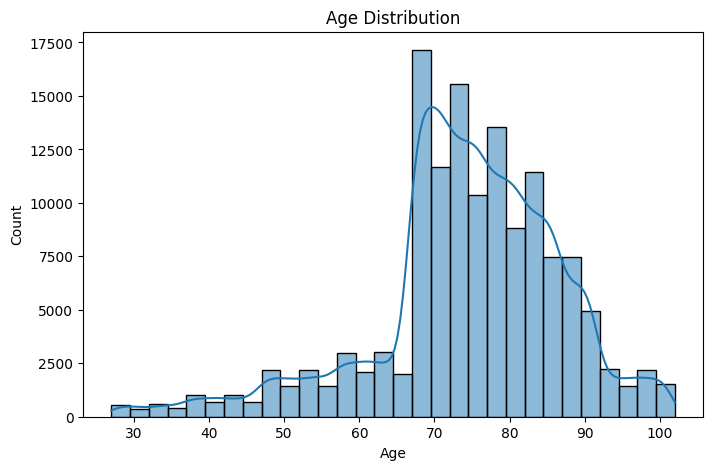

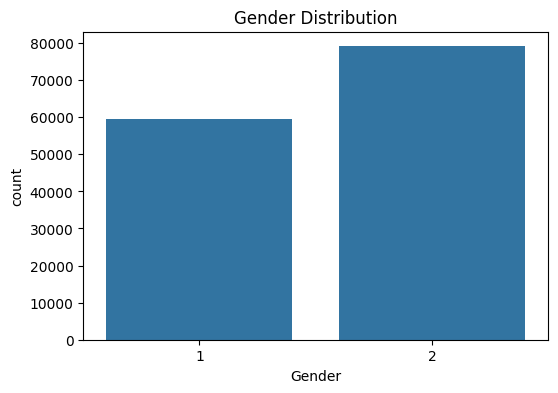

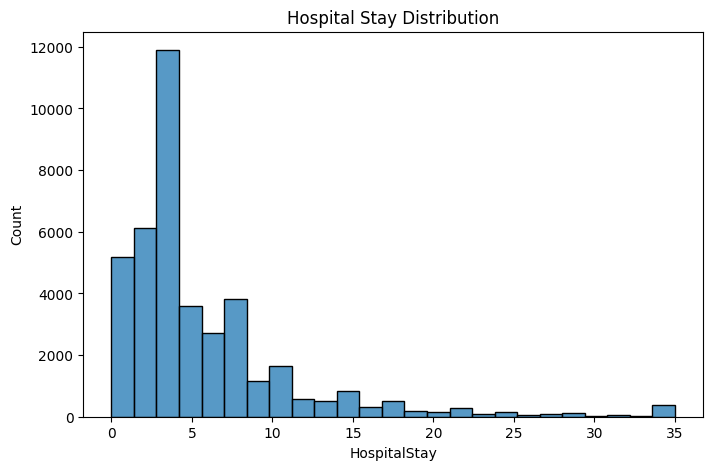

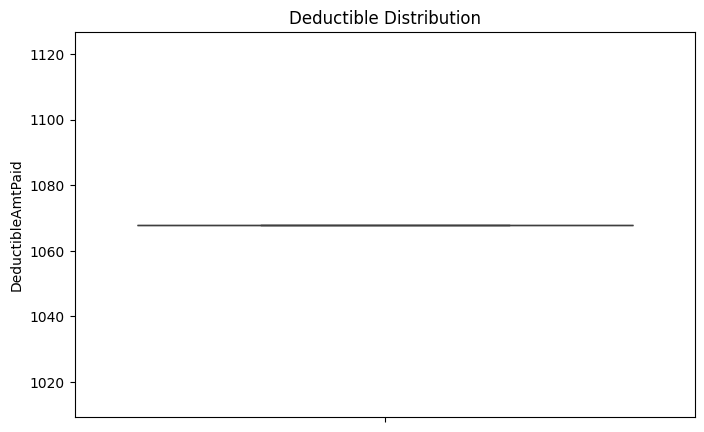

In [ ]:
# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(beneficiary['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=beneficiary)
plt.title("Gender Distribution")
plt.show()

# Hospital Stay Distribution
plt.figure(figsize=(8,5))
sns.histplot(inpatient['HospitalStay'], bins=25)
plt.title("Hospital Stay Distribution")
plt.show()

# Deductible Distribution
plt.figure(figsize=(8,5))
sns.boxplot(y=inpatient['DeductibleAmtPaid'])
plt.title("Deductible Distribution")
plt.show()

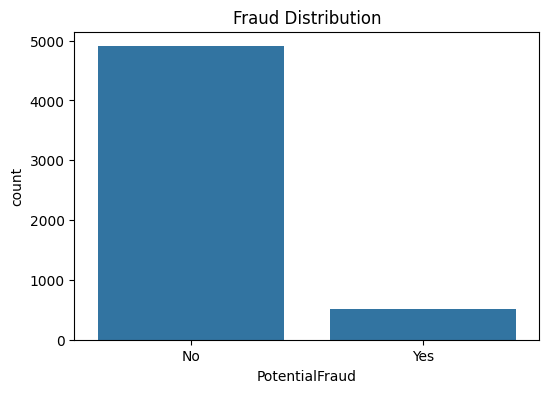

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="PotentialFraud",
    data=final_train
)

plt.title("Fraud Distribution")

plt.show()

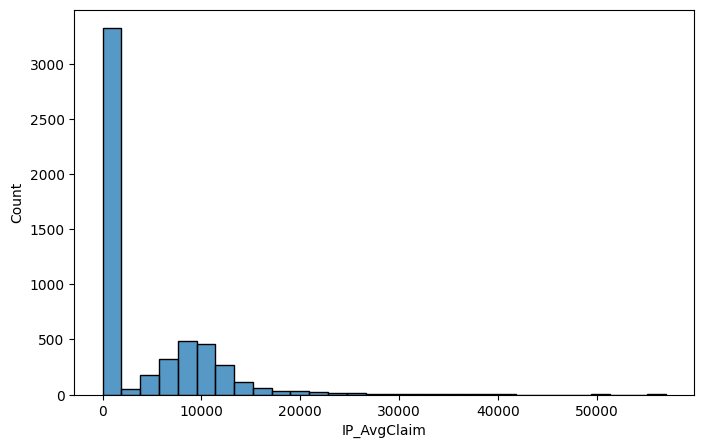

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    final_train["IP_AvgClaim"],
    bins=30
)

plt.show()

,Feature,Importance
0,IP_Claims,0.301282
1,OP_Claims,0.212332
5,AvgHospitalStay,0.169216
2,IP_AvgClaim,0.164048
3,OP_AvgClaim,0.140552
4,IP_AvgDeductible,0.012570


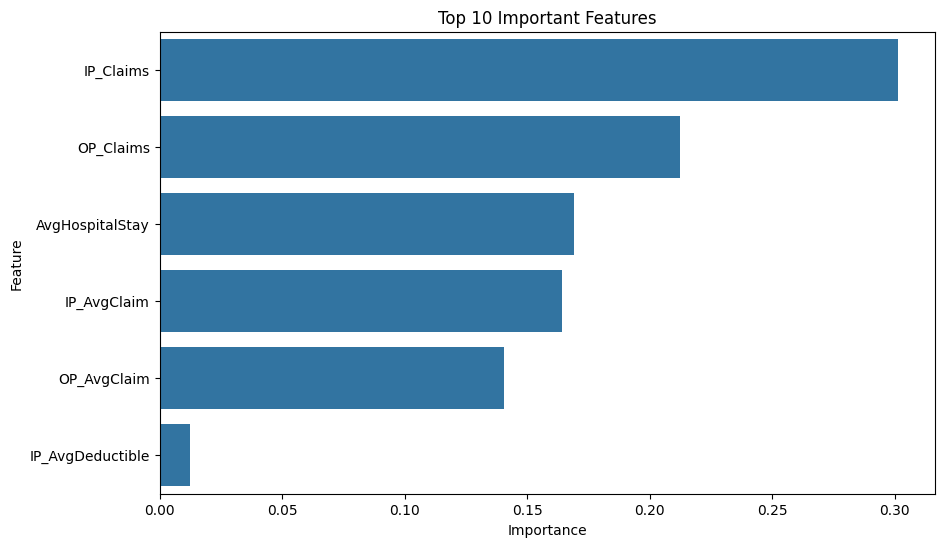

In [ ]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ).fit(X,y).feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

display(importance)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)
plt.title("Top 10 Important Features")
plt.show()

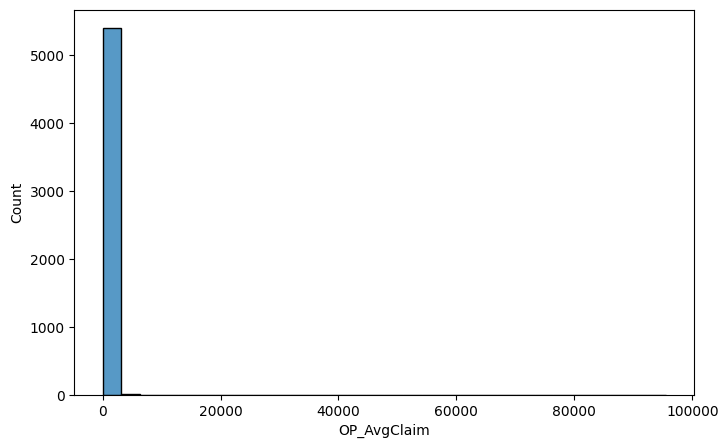

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    final_train["OP_AvgClaim"],
    bins=30
)

plt.show()

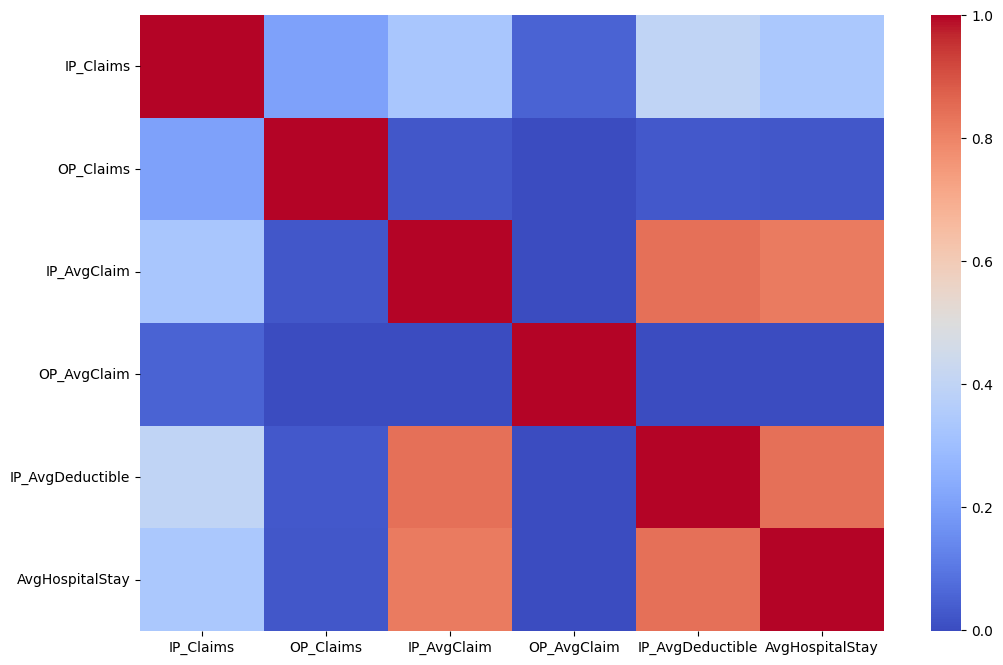

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    final_train.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

In [ ]:
final_train["PotentialFraud"] = final_train[
    "PotentialFraud"
].map(
    {
        "Yes":1,
        "No":0
    }
)

In [ ]:
X = final_train.drop(
    [
        "Provider",
        "PotentialFraud"
    ],
    axis=1
)

y = final_train["PotentialFraud"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [99]:
import joblib

joblib.dump(rf, "fraud_model.pkl")

['fraud_model.pkl']

In [100]:
from google.colab import files
files.download("fraud_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test,pred)
    ])

comparison = pd.DataFrame(
    results,
    columns=["Model","Accuracy"]
)

display(comparison)

,Model,Accuracy
0,Logistic Regression,0.940850
1,Decision Tree,0.925139
2,Random Forest,0.940850


In [ ]:
from sklearn.metrics import accuracy_score

print(
    accuracy_score(
        y_test,
        y_pred
    )
)

0.9390018484288355


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       981
           1       0.72      0.56      0.63       101

    accuracy                           0.94      1082
   macro avg       0.84      0.77      0.80      1082
weighted avg       0.93      0.94      0.94      1082



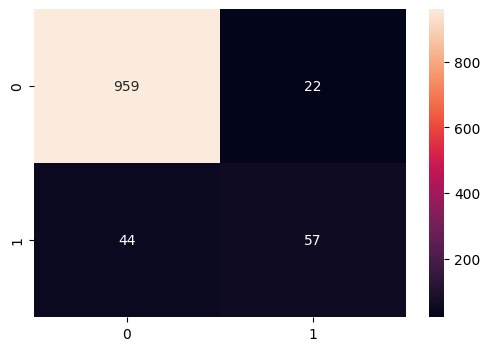

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

print(
    roc_auc_score(
        y_test,
        y_prob
    )
)

0.9551478083588175


In [ ]:
importance = pd.DataFrame(
    {
        "Feature":X.columns,
        "Importance":rf.feature_importances_
    }
)

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
0,IP_Claims,0.294443
1,OP_Claims,0.211889
2,IP_AvgClaim,0.170970
5,AvgHospitalStay,0.164963
3,OP_AvgClaim,0.141475
4,IP_AvgDeductible,0.016260


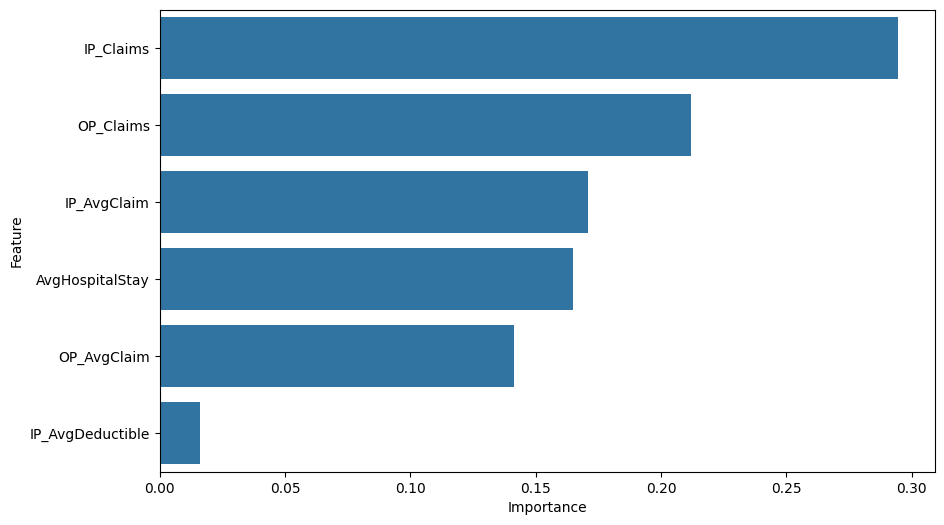

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.show()

In [ ]:
print(unseen.columns.tolist())

['Provider']


In [ ]:
date_columns_bene = ['DOB', 'DOD']

for col in date_columns_bene:
    unseen_beneficiary[col] = pd.to_datetime(unseen_beneficiary[col], errors='coerce')

In [ ]:
date_columns_ip = [
    'ClaimStartDt',
    'ClaimEndDt',
    'AdmissionDt',
    'DischargeDt'
]

for col in date_columns_ip:
    unseen_inpatient[col] = pd.to_datetime(unseen_inpatient[col], errors='coerce')

In [ ]:
date_columns_op = [
    'ClaimStartDt',
    'ClaimEndDt'
]

for col in date_columns_op:
    unseen_outpatient[col] = pd.to_datetime(unseen_outpatient[col], errors='coerce')

In [ ]:
today = pd.Timestamp("2010-12-31")

unseen_beneficiary["Age"] = (
    (today - unseen_beneficiary["DOB"]).dt.days / 365
).astype(int)

In [ ]:
unseen_inpatient["HospitalStay"] = (
    unseen_inpatient["DischargeDt"]
    - unseen_inpatient["AdmissionDt"]
).dt.days

unseen_inpatient["HospitalStay"] = unseen_inpatient["HospitalStay"].fillna(0)

In [ ]:
ip_claims_test = unseen_inpatient.groupby(
    "Provider"
).size().reset_index(name="IP_Claims")

In [ ]:
op_claims_test = unseen_outpatient.groupby(
    "Provider"
).size().reset_index(name="OP_Claims")

In [ ]:
ip_avg_claim_test = unseen_inpatient.groupby(
    "Provider"
)["InscClaimAmtReimbursed"].mean().reset_index()

ip_avg_claim_test.rename(
    columns={
        "InscClaimAmtReimbursed":"IP_AvgClaim"
    },
    inplace=True
)

In [ ]:
op_avg_claim_test = unseen_outpatient.groupby(
    "Provider"
)["InscClaimAmtReimbursed"].mean().reset_index()

op_avg_claim_test.rename(
    columns={
        "InscClaimAmtReimbursed":"OP_AvgClaim"
    },
    inplace=True
)

In [ ]:
ip_avg_deductible_test = unseen_inpatient.groupby(
    "Provider"
)["DeductibleAmtPaid"].mean().reset_index()

ip_avg_deductible_test.rename(
    columns={
        "DeductibleAmtPaid":"IP_AvgDeductible"
    },
    inplace=True
)

In [ ]:
avg_stay_test = unseen_inpatient.groupby(
    "Provider"
)["HospitalStay"].mean().reset_index()

avg_stay_test.rename(
    columns={
        "HospitalStay":"AvgHospitalStay"
    },
    inplace=True
)

In [ ]:
final_test = unseen.copy()

final_test = final_test.merge(
    ip_claims_test,
    on="Provider",
    how="left"
)

final_test = final_test.merge(
    op_claims_test,
    on="Provider",
    how="left"
)

final_test = final_test.merge(
    ip_avg_claim_test,
    on="Provider",
    how="left"
)

final_test = final_test.merge(
    op_avg_claim_test,
    on="Provider",
    how="left"
)

final_test = final_test.merge(
    ip_avg_deductible_test,
    on="Provider",
    how="left"
)

final_test = final_test.merge(
    avg_stay_test,
    on="Provider",
    how="left"
)

final_test.fillna(0,inplace=True)

In [ ]:
X_unseen = final_test.drop(
    "Provider",
    axis=1
)

# Business Recommendations

1. Providers with unusually high reimbursement amounts should be audited.

2. Providers with excessive inpatient claims should be monitored.

3. Providers with long hospital stays should be reviewed.

4. Providers serving an unusually high number of beneficiaries should be flagged.

5. Machine learning predictions should be combined with manual investigations.

6. Retrain the fraud detection model periodically using new claims data.

# Conclusion

A machine learning model was developed to identify potentially fraudulent healthcare providers.

The project included data management, exploratory data analysis, feature engineering, feature selection, model training, evaluation, and prediction on unseen providers.

Random Forest performed well and was used to generate the final submission file. The model can assist insurance companies in identifying providers for further investigation and reducing fraudulent healthcare claims.

In [ ]:
probability = rf.predict_proba(X_unseen)[:,1]

prediction = rf.predict(X_unseen)

In [ ]:
prediction = np.where(
    prediction==1,
    "Yes",
    "No"
)

In [ ]:
submission = pd.DataFrame({
    "Provider": final_test["Provider"],
    "Probability": probability,
    "Predicted Class": prediction
})

submission.head()

,Provider,Probability,Predicted Class
0,PRV51002,0.000000,No
1,PRV51006,0.000000,No
2,PRV51009,0.010000,No
3,PRV51010,0.023333,No
4,PRV51018,0.000000,No


In [ ]:
submission.to_csv(
    "Rishitha_Submission.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download(
    "Rishitha_Submission.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>